#**class_07_optimization_regression**

##**Agenda**
- **PART 1 — Why Optimization Exists**
- **PART 2 — Cost Function (Mean Squared Error)**
- **PART 3 — Convexity & Global Minimum**
- **PART 4 — Gradient Descent**
- **PART 5 — Learning Rate (α)**
- **PART 6 — Variants of Gradient Descent**
- **PART 7 — Assumptions & Their Impact**
- **PART 8 — Gradient Descent vs Closed Form Solution**


#**PART 1 — Why Optimization Exists**

**The Learning Problem**

- Suppose we have data:
| Experience | Salary |
| ---------- | ------ |
| 1          | 30K    |
| 2          | 40K    |
| 3          | 50K    |
| 4          | 60K    |


**We want a model:**

- Salary = $$β₀ + β₁ × Experience$$


**Question:**

- Which values of β₀ and β₁ should we choose?

**Option 1 — Guess**
- β₀ = 10
- β₁ = 5

Maybe good.
Maybe terrible.

No guarantee.

**Option 2 — Learn Systematically**

- Find parameters that minimize prediction error.

This is Optimization.


**Optimization Definition**

- Optimization is the process of finding parameter values that minimize a predefined objective function.


**Machine Learning Perspective**

- Learning = Optimization

**Training a model means:**

- Find parameters
↓
- Reduce error
↓
- Improve predictions




**Search Space Intuition**

- For one parameter:

  - β

Search space = line


- For two parameters:

  - β₀, β₁

Search space = plane

- For 100 features:

  - β₁, β₂, β₃ ... β₁₀₀

Search space = 100-dimensional space

Optimization navigates this space efficiently.

#**PART 2 — Cost Function (Mean Squared Error)**

**What is a Cost Function?**

- A Cost Function measures:

   - "How bad is the model?"

- Smaller cost:
  - Better model

- Larger cost:
  - Worse model



**Why Cost Functions Matter

- Optimization needs a target.

**Without a cost function:**

 - There is no way to know whether a model improved.


**Mean Squared Error (MSE)**

- The most common cost function for Linear Regression.




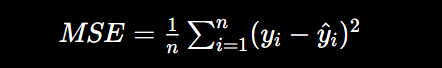

**Where:**
- yᵢ = actual value
- ŷᵢ = predicted value
- n = total observations



**Example**


- Actual:

  - [10,20,30]

- Predicted:

  - [12,18,32]

- Errors:

  - [-2,+2,-2]

- Squared Errors:

  - 4 + 4 + 4 = 12

**MSE:**

- 12 / 3 = 4


**Python Example**

In [ ]:
import numpy as np

actual = np.array([10,20,30])
predicted = np.array([12,18,32])

mse = np.mean((actual - predicted)**2)

print(mse)

4.0


**Why MSE?**


**1. Penalizes Large Errors**

Error:

- 2 → 4
- 10 → 100

Large mistakes become much more expensive.

**2. Smooth Function**

- The function is differentiable everywhere.

- Gradient-based optimization becomes possible.


**3. Convex for Linear Regression**

- Only one minimum exists.

Optimization becomes easier.

#**PART 3 — Convexity & Global Minimum**

**What is Convexity?**

- A function is convex if:

**For any two points:**

- The line connecting them lies above the curve.


**Mathematical Intuition**

- Convex functions have:

  - One valley
  - One bottom
  - One global optimum


**Why Convexity Matters**

- Optimization becomes predictable.

No bad local minima.

**Linear Regression Property**

- Linear Model + MSE

- ⇒ Convex Cost Function


This is one of the biggest reasons Linear Regression is mathematically elegant.

- Global vs Local Minima


- Global Minimum
   - Best solution overall.

- Local Minimum
   - Looks optimal locally.

Not necessarily best globally.

#**PART 4 — Gradient Descent**

**Core Idea**

- Suppose you are standing on a mountain blindfolded.


**Question:**
- How do you reach the bottom?

**Answer:**
- Move in the steepest downward direction repeatedly.

This is Gradient Descent.


**What is a Gradient?**
- Gradient measures:

   - Direction of maximum increase.


**Key Insight**

- Positive Gradient:

  - Going uphill

- Negative Gradient:

  - Going downhill

- Optimization wants:

  - Negative Gradient


**Why Gradient Descent Works**

- Gradient points toward:

   - Maximum increase.

- Negative gradient points toward:

   - Maximum decrease.

- Therefore:

   - Every step attempts to reduce error as efficiently as possible.


**Python Example**


In [ ]:
x = 10

learning_rate = 0.1

for i in range(20):
    gradient = 2*x
    x = x - learning_rate * gradient

print(x)

0.11529215046068471


#**PART 5 — Learning Rate (α)**

**Definition**

- Learning Rate controls:

  - How large each update step should be.


**Update Equation**

$$β_{new}=β_{old}-α∇J(β)$$

α determines step size.


**Case 1 — Too Small**
- α = 0.000001

**Result:**

- Very slow learning


**&Visualization:**

- . . . . . . . . .

Tiny steps.


**Case 2 — Too Large**
- α = 100

**Result:**

- Overshooting.


**Visualization:**

- Left → Right → Left → Right

Never settles.


**Case 3 — Proper Learning Rate**
- α = 0.01


**Result:**

- Fast stable convergence.

**Learning Rate Table**
| Learning Rate | Behavior            |
| ------------- | ------------------- |
| Too Small     | Slow convergence    |
| Too Large     | Divergence          |
| Proper        | Stable optimization |


#**PART 6 — Variants of Gradient Descent**

**Batch Gradient Descent**



Uses entire dataset.

- Compute all gradients
↓
- Update once

**Advantages:**

- Stable
- Accurate

**Disadvantages:**

- Slow for large datasets


**Stochastic Gradient Descent (SGD)**

Uses one sample at a time.

- One sample
↓
- One update

**Advantages:**
- Fast
- Scalable

**Disadvantages:**
- Noisy updates


**Mini-Batch Gradient Descent**

Most commonly used today.

- Uses:

  - 32
  - 64
  - 128
  - 256

samples per update.

**Balances:**
- Speed
- Stability

**Comparison**
| Method     | Speed    | Stability |
| ---------- | -------- | --------- |
| Batch      | Slow     | High      |
| SGD        | Fast     | Low       |
| Mini-Batch | Balanced | Balanced  |






#**PART 7 — Assumptions & Their Impact**

**Linear Regression Assumptions**
- Linearity: The expected value of the target is a linear combination of the features.
- Independence: Each observation should be independent of every other observation.
- Homoscedasticity: The variance of the errors should remain roughly constant across all predicted values.
- No Multicollinearity: It means the features shouldn't contain nearly identical information.
- Normality of Errors: Residuals should approximately follow a normal distribution.


**Optimization Impact**
| Assumption Violated | Impact              |
| ------------------- | ------------------- |
| Multicollinearity   | Unstable gradients  |
| Non-linearity       | Poor fit            |
| Outliers            | Distorted gradients |
| Heteroscedasticity  | Poor inference      |



**Multicollinearity Example**

- Features:

  - Age
  - Age × 12 (months)

Nearly identical information.

Optimization struggles to assign weights.


#**PART 8 — Gradient Descent vs Closed Form Solution**

**Normal Equation**

- Linear Regression has a direct mathematical solution.


$$β=(X^TX)^{−1}X^Ty$$


**This is called:**

- Normal Equation.

**Characteristics**

Produces:

- Exact solution

- No iteration required.


**Limitations**

Requires:

- Matrix inversion

- Expensive for large feature sets.

**Comparison**
| Normal Equation  | Gradient Descent      |
| ---------------- | --------------------- |
| Exact            | Iterative             |
| Matrix inversion | No inversion          |
| Poor scalability | Excellent scalability |
| Small datasets   | Large datasets        |




#**PART 9 — Optimization in Modern ML**

**Why Closed Form Solutions Disappear**

For Linear Regression:

- Exact solution exists.

For Neural Networks:

- No exact solution exists.


Millions or billions of parameters make closed-form optimization impossible.


**Modern ML Reality**

- Optimization drives:

   - Deep Learning
   - Transformers
   - Diffusion Models
   - Reinforcement Learning
   - Generative AI


**Advanced Interview Insight**

Every Machine Learning model ultimately solves:

- Minimize Loss

The difference between algorithms is often:
- How they optimize

rather than
- What they optimize**


**Master Summary Table**
| Concept          | Key Idea                         |
| ---------------- | -------------------------------- |
| Optimization     | Minimize prediction error        |
| MSE              | Measures model error             |
| Convexity        | Guarantees global minimum        |
| Gradient         | Direction of steepest increase   |
| Gradient Descent | Iterative optimization           |
| Learning Rate    | Controls step size               |
| SGD              | Faster optimization              |
| Normal Equation  | Exact linear regression solution |
